In [1]:
# Imports

import helpers.helper_functions as hf
import mne
import os.path as op
from mne.channels import combine_channels
import pandas as pd
from mne.beamformer import make_lcmv, apply_lcmv_epochs
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import hilbert
from helpers import test_circ_plot
from helpers import stc_helper
ss = hf.settings_dict()


In [2]:
subject_index = 6
trial = 4
event_id = 4
event_name = '4'
duty_cycle = ss['event_name_list'][event_id-1]
tmin = 2.2
figsize = (6,7)
cut_coords = (0,0)
dpi = 100
alpha = 0.05

Reading forward solution from /media/elias/data/thesis_intermediate/data/scratch/fwd/0014_TAG-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (1211 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame


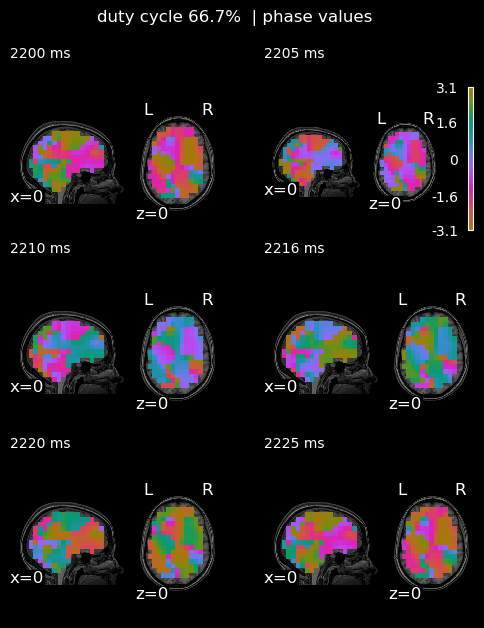

In [3]:
import math

subject = ss['subject_id_list'][subject_index]
hilbert_stc_file = Path(ss['hilbert_dir']) / subject / event_name / f"{subject}-trial-{trial}-hilbert-vol.stc"
stc = mne.read_source_estimate(hilbert_stc_file)

fwd = hf.load_fwd_model(subject_index)
src = fwd['src']

stcs = []
t_points = []

for i in range(6):
    t_point = tmin+(i*0.005)
    time_point_stc = stc.copy().crop(tmin=t_point, tmax=t_point)
    stcs.append(time_point_stc)
    t_points.append(f"{math.ceil(t_point*1000)} ms")

test_circ_plot.plot_circ_stat_map(
    stcs=stcs,
    src=src,
    subject=subject,
    display_mode="xz",
    subjects_dir=ss['fs_subjects_dir'],
    title=f'duty cycle {duty_cycle}%  | phase values',
    fig_titles=t_points,
    nrows=3,
    ncols=2,
    figsize=figsize,
    cut_coords=cut_coords,
    dpi=dpi,

)

Reading forward solution from /media/elias/data/thesis_intermediate/data/scratch/fwd/0014_TAG-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (1211 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame


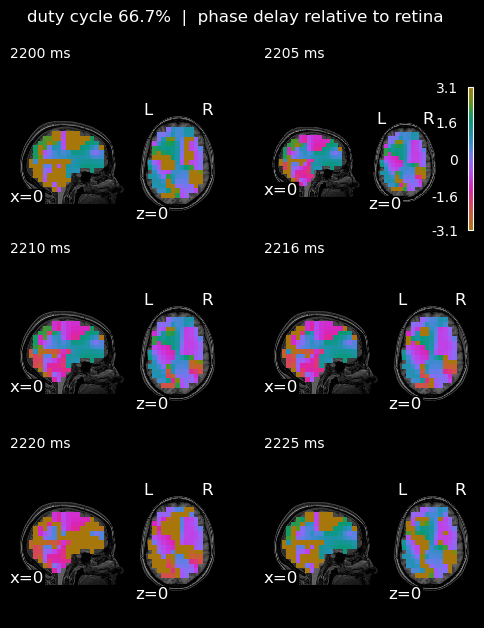

In [4]:

subject = ss['subject_id_list'][subject_index]
hilbert_stc_file = Path(ss['hilbert_ref_dir']) / subject / event_name / f"{subject}-trial{trial}-ret-ref-vol.stc"
stc = mne.read_source_estimate(hilbert_stc_file)

fwd = hf.load_fwd_model(subject_index)
src = fwd['src']

stcs = []
t_points = []

for i in range(6):
    t_point = tmin+(i*0.005)
    time_point_stc = stc.copy().crop(tmin=t_point, tmax=t_point)
    stcs.append(time_point_stc)
    t_points.append(f"{math.ceil(t_point*1000)} ms")

test_circ_plot.plot_circ_stat_map(
    stcs=stcs,
    src=src,
    subject=subject,
    display_mode="xz",
    subjects_dir=ss['fs_subjects_dir'],
    title=f"duty cycle {duty_cycle}%  |  phase delay relative to retina",
    fig_titles=t_points,
    nrows=3,
    ncols=2,
    figsize=figsize,
    cut_coords=cut_coords,
    dpi=dpi,
    )

In [5]:
figsize = (8,6)
cut_coords = (0,0)
dpi = 100
alpha = 0.05

Reading forward solution from /media/elias/data/thesis_intermediate/data/scratch/fwd/0005_3SJ-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (1440 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame
Reading forward solution from /media/elias/data/thesis_intermediate/data/scratch/fwd/0002_TCZ-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (1868 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame
Reading forward solution from /media/elias/data/thesis_intermediate/data/scratch/fwd/0009_YGZ-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named

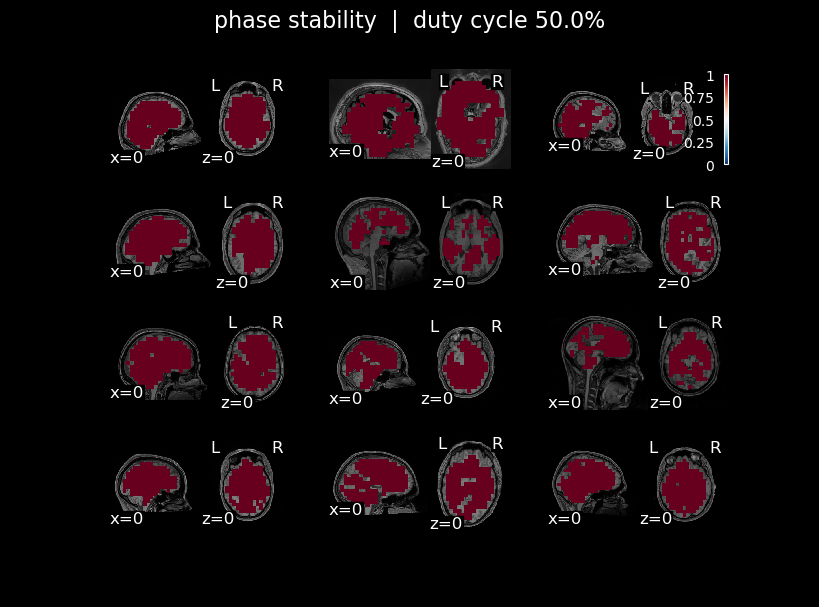

ValueError: all input arrays must have the same shape

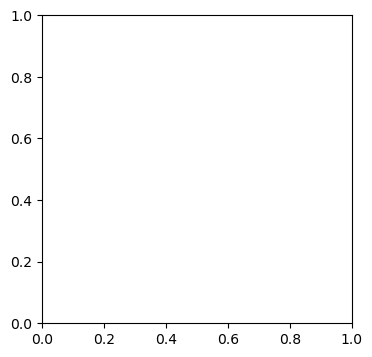

In [7]:
phase_delay_stcs = []
subjects = []
srcs = []
t1s = []
act_percent = []
phase_act_percent = []

for subject_index in ss['subject_idx_list']:

    event_name = str(event_id)
    duty_cycle = ss['event_name_list'][event_id - 1]
    subjects_dir = ss['fs_subjects_dir']
    subject = ss['subject_id_list'][subject_index]

    df = pd.read_csv(Path(ss['stc_dir']) / subject / event_name / f"{subject}-event-{event_name}-mask.csv")
    stc_mask = df["voxels"].values

    # load phase delay p value stc data
    hilbert_stc_file = Path(ss['hilbert_ref_dir']) / subject / event_name / f"{subject}-event-{event_name}-p-vol.stc"
    stc = mne.read_source_estimate(hilbert_stc_file)

    p_vals  = stc.data[:, 0]
    sig_stc = stc.copy()

    sig_stc.data[stc_mask, :] = 0
    sig_stc.data[~stc_mask, :] = 0.5
    sig_stc.data = (p_vals < alpha).astype(float)[:, np.newaxis]

    phase_delay_stcs.append(sig_stc)

    phase_act = ((sig_stc.data == True).sum() / sig_stc.data.sum())*100
    phase_act_percent.append(phase_act)

    act = ((stc_mask == False).sum() / stc_mask.sum())*100
    act_percent.append(act)

    subjects.append(f"{subject}")

    fwd = hf.load_fwd_model(subject_index)
    src = fwd['src']

    srcs.append(src)

    t1 = op.join(subjects_dir, subject, 'mri', 'T1.mgz')

    t1s.append(t1)

empty_titles = [''] * 12

stc_helper.plot_stcs(
    stcs=phase_delay_stcs,
    srcs=srcs,
    t1s=t1s,
    display_mode="xz",
    title=f'phase stability  |  duty cycle {duty_cycle}%',
    fig_titles=empty_titles,
    nrows=4,
    ncols=3,
    figsize=figsize,
    cut_coords=cut_coords,
    dpi=dpi,
    )

fig, ax = plt.subplots(figsize=(4, 4))

plt.plot(np.stack(subjects), np.stack(act_percent), np.stack(subjects), np.stack(phase_act_percent), '-o', c='k', lw=2)
ax.set_xlabel('Subjects')
ax.set_xticklabels(np.stack(subjects), rotation=45)
ax.set_xticks(np.stack(subjects))
ax.set_ylabel('Brain response volume (% of brain)')


